In [1]:
import pandas as pd
import numpy as np
import itertools
import statsmodels.api as sm
import matplotlib.pyplot as plt

### Lab 6

#### Task 6.5.1
Here we apply the best subset selection approach to the Hitters data. We
wish to predict a baseball player’s Salary on the basis of various statistics
associated with performance in the previous year

First of all, we note that the Salary variable is missing for some of the
players.

In [7]:
hitters = pd.read_csv("data/Hitters.csv")
print(f"Lost salaries {hitters["Salary"].isna().sum()}")

Lost salaries 59


Hence we see that Salary is missing for 59 players. Remove them

In [8]:
hitters = hitters.dropna()
print(f"The data set size: {hitters.shape}\n")

The data set size: (263, 20)



In [9]:
hitters.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263 entries, 1 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      263 non-null    int64  
 1   Hits       263 non-null    int64  
 2   HmRun      263 non-null    int64  
 3   Runs       263 non-null    int64  
 4   RBI        263 non-null    int64  
 5   Walks      263 non-null    int64  
 6   Years      263 non-null    int64  
 7   CAtBat     263 non-null    int64  
 8   CHits      263 non-null    int64  
 9   CHmRun     263 non-null    int64  
 10  CRuns      263 non-null    int64  
 11  CRBI       263 non-null    int64  
 12  CWalks     263 non-null    int64  
 13  League     263 non-null    object 
 14  Division   263 non-null    object 
 15  PutOuts    263 non-null    int64  
 16  Assists    263 non-null    int64  
 17  Errors     263 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  263 non-null    object 
dtypes: float64(1), 

In [10]:
hitters = pd.get_dummies(hitters, columns=["League", "Division", "NewLeague"], drop_first=True, dtype=int)

In [12]:
hitters.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,League_N,Division_W,NewLeague_N
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,475.0,1,1,1
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,480.0,0,1,0
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,500.0,1,0,1
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,91.5,1,0,1
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,282,421,25,750.0,0,1,0


In [13]:
X = hitters.drop(columns=["Salary"])
X = sm.add_constant(X)
y = hitters["Salary"]

In [14]:
# the function for estimating one certain combination of variables
def process_subset(feature_set):
    model = sm.OLS(y, X[list(feature_set)]).fit()
    RSS = model.ssr
    return {"model": model, "RSS": RSS, "features": feature_set}


# the function for searching best model within all combinations k
def get_best_of_k(k):
    # gether all features without const
    features_without_const = [col for col in X.columns if col != 'const']
    
    results = []
    # trying all possible combinations k size
    for combo in itertools.combinations(features_without_const, k):
        # adding const in every single model
        combo_with_const = list(combo) + ['const']
        results.append(process_subset(combo_with_const))

    # return the model with the minimum RSS
    df_results = pd.DataFrame(results)
    best_model = df_results.loc[df_results['RSS'].idxmin()]
    return best_model

In [17]:
hitters.shape

(263, 20)

In [18]:
# Start loop
best_models = {}
for k in range(1, 20):
    best_models[k] = get_best_of_k(k)
    print(f"The model with size k={k} is done.")

print("\n--- All models are computed ---")

The model with size k=1 is done.
The model with size k=2 is done.
The model with size k=3 is done.
The model with size k=4 is done.
The model with size k=5 is done.
The model with size k=6 is done.
The model with size k=7 is done.
The model with size k=8 is done.
The model with size k=9 is done.
The model with size k=10 is done.
The model with size k=11 is done.
The model with size k=12 is done.
The model with size k=13 is done.
The model with size k=14 is done.
The model with size k=15 is done.
The model with size k=16 is done.
The model with size k=17 is done.
The model with size k=18 is done.
The model with size k=19 is done.

--- All models are computed ---


In [19]:
summary_data = []

full_model = best_models[19]["model"]
sig2 = full_model.ssr / full_model.df_resid
n = len(y)

for k, row in best_models.items():
    model = row["model"]
    d = len(row['features'])
    cp = (row['RSS'] / sig2) - n + 2 * d
    
    summary_data.append({
        "k": k,
        "RSS": row['RSS'],
        "R2": model.rsquared,
        "Adj_R2": model.rsquared_adj,
        "Cp": cp,
        "BIC": model.bic
    })

df_summary = pd.DataFrame(summary_data)

# searching the best points
best_adj_r2 = df_summary.loc[df_summary["Adj_R2"].idxmax()]
best_cp = df_summary.loc[df_summary["Cp"].idxmin()]
best_bic = df_summary.loc[df_summary["BIC"].idxmin()]

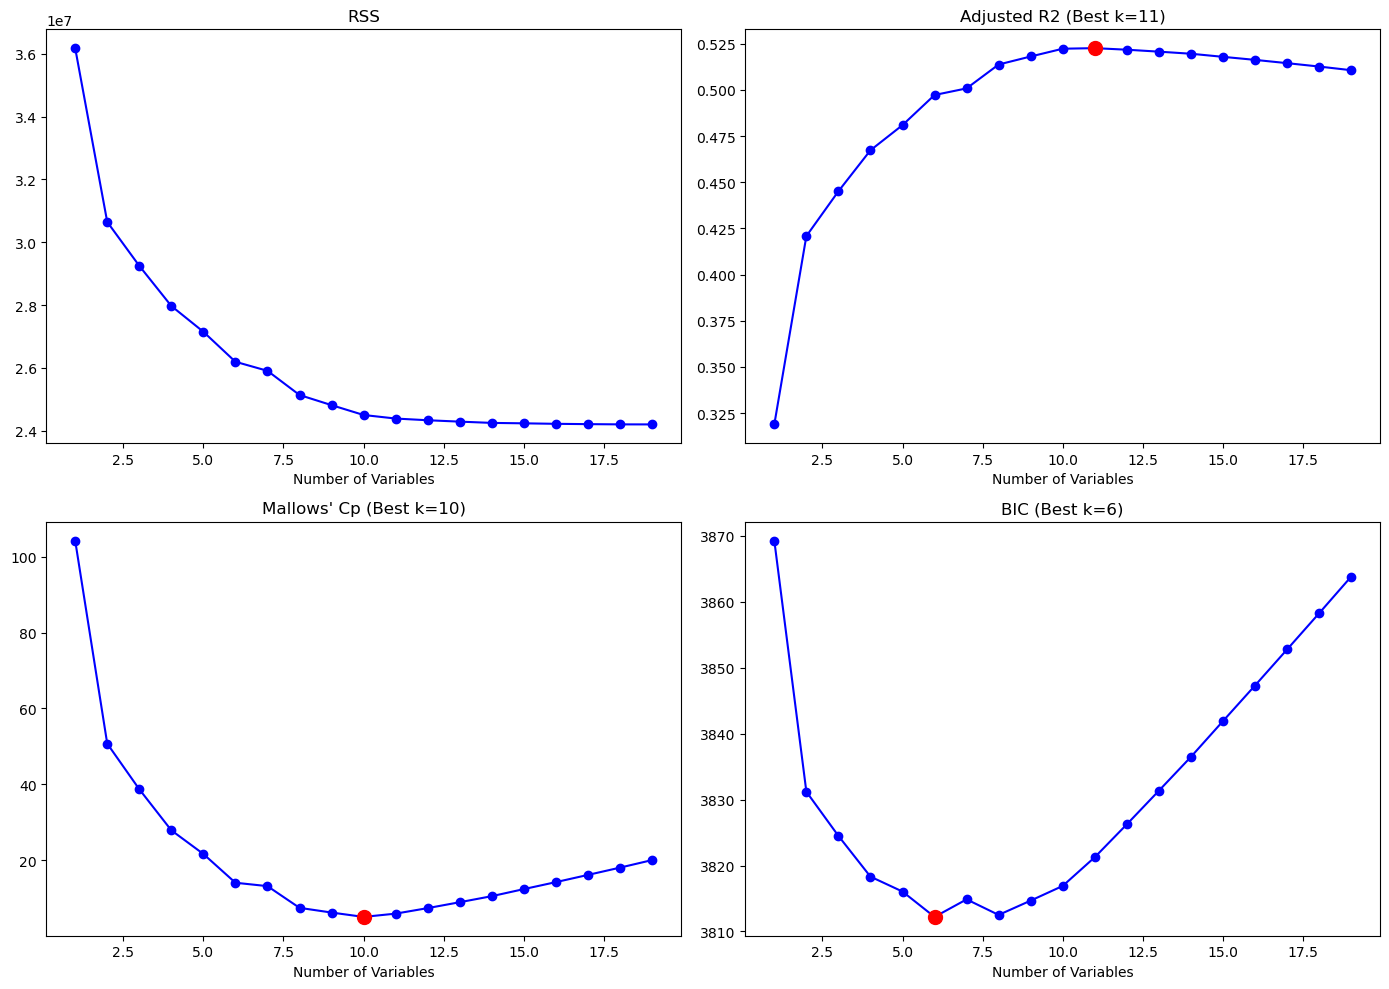

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. RSS
axes[0, 0].plot(df_summary["k"], df_summary["RSS"], marker="o", color="b")
axes[0, 0].set_title("RSS")
axes[0, 0].set_xlabel("Number of Variables")

# 2. Adjusted R2
axes[0, 1].plot(df_summary["k"], df_summary["Adj_R2"], marker="o", color="b")
axes[0, 1].scatter(best_adj_r2["k"], best_adj_r2["Adj_R2"], color="red", s=100, zorder=5)
axes[0, 1].set_title(f"Adjusted R2 (Best k={int(best_adj_r2['k'])})")
axes[0, 1].set_xlabel("Number of Variables")

# 3. Cp
axes[1, 0].plot(df_summary["k"], df_summary["Cp"], marker="o", color="b")
axes[1, 0].scatter(best_cp["k"], best_cp["Cp"], color="red", s=100, zorder=5)
axes[1, 0].set_title(f"Mallows' Cp (Best k={int(best_cp['k'])})")
axes[1, 0].set_xlabel("Number of Variables")

# 4. BIC
axes[1, 1].plot(df_summary["k"], df_summary["BIC"], marker="o", color="b")
axes[1, 1].scatter(best_bic["k"], best_bic["BIC"], color="red", s=100, zorder=5)
axes[1, 1].set_title(f"BIC (Best k={int(best_bic['k'])})")
axes[1, 1].set_xlabel("Number of Variables")

plt.tight_layout()
plt.show()

In [24]:
print("--- Coefficients best 6-variables model (BIC) ---")
best_6_model = best_models[6]["model"]
print(best_6_model.params)

--- Coefficients best 6-variables model (BIC) ---
AtBat          -1.868589
Hits            7.604398
Walks           3.697647
CRBI            0.643017
PutOuts         0.264308
Division_W   -122.951534
const          91.511798
dtype: float64


Based on computed and lotted information we can draw next conslusions:
- The more variables we add to the model the more $R^2$ we get and the less RSS
- The only one measure that should be maximum for choosing is adjusted $R^2$. Here we cann see that when k=11 then adjusted $R^2$ has maximum value
- The $C_p$ measure has chosen the model with 10 k. It means that the measure does not have big benalty for amount of features
- In contrast, the BIC meassure include $log$ penalty for using bug amount of features, therefore in this certain measure the best value was riached when k=6